# Build MTH5 from INTERMAGNET data

While the USGS handles most of the data collected by North American observatories, [the INTERMAGNET program](https://intermagnet.org/) serves as a repository for observatories in other nations across the globe. This example notebook will show you how to request data from the INTERMAGNET service and load the data into an MTH5 object you can then manipulate.

To most effectively use the API, you will need to know which observatories you would like to request data from, the type(s) of data that you want, and the range of dates you want to sample over.  See [INTERMAGNET Web Services](https://imag-data.bgs.ac.uk/GIN_V1/) for more information on allowed options.

This example will pull two days' worth of data from the observatory in Conrad, Austria (IAGA code WIC) for the x and y components of calibrated data ('adjusted').

In [1]:
import pandas as pd

from mth5.clients import MakeMTH5



## Create a request DataFrame

We will be using ``MakeMTH5.from_intermag()`` to build this MTH5 file. It takes in a pandas ``DataFrame`` object to build request URLs and resolve them. We recommend specifying all of these options, as seen in the example below. You can also add additional columns to your ``DataFrame`` if you would like to query multiple stations or multiple data ranges.

| Column | Description | Options |
|--------|-------------|---------|
| observatory | The observatory's three-letter IAGA code. Be aware that some of these observatories may be closed or no longer adhere to INTERMAGNET's data standards. More information on each observatory can be found [here](https://imag-data.bgs.ac.uk/GIN_V1/GINServices?Request=GetCapabilities&format=html). | AAE, ABG, ABK, AIA, ALE, AMS, API, AQU, ARS, ASC, ASP, BDV, BEL, BFE, BFO, BLC, BMT, BNG, BOU, BOX, BRD, BRW, BSL, CBB, CKI, CLF, CMO, CNB, CNH, CPL, CSY, CTA, CYG, CZT, DED, DLR, DLT, DMC, DOU, DRV, DUR, EBR, ESK, EYR, FCC, FRD, FRN, FUR, GAN, GCK, GDH, GLN, GNA, GNG, GUA, GUI, GZH, HAD, HBK, HER, HLP, HON, HRB, HRN, HUA, HYB, IPM, IQA, IRT, ISK, IZN, JAI, JCO, KAK, KDU, KEP, KHB, KIR, KIV, KMH, KNY, KOU, LER, LNP, LON, LOV, LRM, LVV, LYC, LZH, MAB, MAW, MBC, MBO, MCQ, MEA, MGD, MID, MLT, MMB, MZL, NAQ, NCK, NEW, NGK, NUR, NVS, ORC, OTT, PAF, PAG, PBQ, PEG, PET, PHU, PIL, PPT, PST, QSB, RES, REU, SBA, SBL, SFS, SHE, SHU, SIT, SJG, SOD, SPG, SPT, STJ, STT, SUA, TAM, TAN, TDC, THL, THY, TIK, TSU, TTB, TUC, UPS, VAL, VIC, VNA, VOS, VSS, WIC, WMQ, WNG, YAK, YKC|
| type | The type of data to download | best-avail (default), definitive, quasi-def, adjusted, reported |
| elements | Components or elements of the geomagnetic data to download, should be a list| D, DIST, DST, E, E-E, E-N, F, G, H, SQ, SV, UK1, UK2, UK3, UK4, X, Y, ZD, DIST, DST, E, E-E, E-N, F, G, H, SQ, SV, UK1, UK2, UK3, UK4, X, Y, Z |
| sampling_period | Sampling period of data to download in seconds | 1, 60 |
| start | Start time (YYYY-MM-DDThh:mm:ss)  in UTC time| |
| end | End time (YYYY-MM-DDThh:mm:ss) in UTC time||

In [2]:
request_df = pd.DataFrame(
    {
        "observatory": ["wic"],
        "type": ["adjusted"],
        "elements": [["x", "y"]],
        "sampling_period": [1],
        "start": [
            "2021-03-10T00:00:00",
        ],
        "end": [
            "2021-03-12T00:00:00",
        ],
    }
)

In [3]:
request_df

,observatory,type,elements,sampling_period,start,end
0,wic,adjusted,"[x, y]",1,2021-03-10T00:00:00,2021-03-12T00:00:00


### Adding Run ID

MTH5 will automatically assign names to different windows of time using the format `f"sp{sampling_period}_{count:03}"`. So the first run in our example will be `sp1_001`. If you prefer naming the runs yourself, you can add a run column and name them as you like.  

## Create MTH5

With our request dataframe in place, we can now pass it into MakeMTH5. The file name will be created automatically as `intermag_{list of observatories}_{list of elements}.h5`.

The `interact` argument here simply tells MTH5 what to do after it has compiled the file. If `interact` is set to `True` then the file stays open and the returned object is the opened MTH5 file object.  If `interact` is set to `False` (the default) then the MTH5 is closed and the returned object is the path to the created file.

In [7]:
m = MakeMTH5.from_intermag(request_df, mth5_version="0.2.0")

2026-05-15T12:46:59.750847-0600 | WARNING | mth5.mth5 | open_mth5 | line: 795 | intermag_wic_xy.h5 will be overwritten in 'w' mode
2026-05-15T12:47:00.040629-0600 | INFO | mth5.mth5 | _initialize_file | line: 900 | Initialized MTH5 0.2.0 file C:\Users\jpopelar\OneDrive - DOI\Documents\mtproject\mth5\docs\examples\notebooks\intermag_wic_xy.h5 in mode w
2026-05-15T12:47:04.463932-0600 | WARNING | mt_timeseries.run_ts | validate_metadata | line: 1102 | sample rate of dataset 1.0 is different than metadata sample rate 0.0 updating metatdata value to 1.0
2026-05-15T12:47:05.036254-0600 | INFO | mth5.mth5 | close_mth5 | line: 1035 | Flushing and closing C:\Users\jpopelar\OneDrive - DOI\Documents\mtproject\mth5\docs\examples\notebooks\intermag_wic_xy.h5
2026-05-15T12:47:05.038255-0600 | WARNING | mth5.mth5 | filename | line: 381 | MTH5 file is not open or has not been created yet. Returning default name


### Check to make sure everything was downloaded properly

Now we'll make a fresh HDF5 object to read the data with.

In [8]:
from mth5.mth5 import MTH5

m = MTH5(file_version="0.2.0")
m.open_mth5("intermag_wic_xy.h5")

m.channel_summary.summarize()
m.channel_summary.to_dataframe()

,survey,station,run,latitude,longitude,elevation,component,start,end,n_samples,sample_rate,measurement_type,azimuth,tilt,units,has_data,hdf5_reference,run_hdf5_reference,station_hdf5_reference
0,INTERMAG,Conrad,sp1_001,47.931,15.866,0.0,hx,2021-03-10 00:00:00+00:00,2021-03-11 23:59:59+00:00,172800,1.0,magnetic,0.0,0.0,nanoTesla,True,<HDF5 object reference>,<HDF5 object reference>,<HDF5 object reference>
1,INTERMAG,Conrad,sp1_001,47.931,15.866,0.0,hy,2021-03-10 00:00:00+00:00,2021-03-11 23:59:59+00:00,172800,1.0,magnetic,90.0,0.0,nanoTesla,True,<HDF5 object reference>,<HDF5 object reference>,<HDF5 object reference>


### Have a look at a run

Finally, once we have verified our file has everything we expect it to have, we can start using it like any other MTH5. For example, if we wanted to see a data plot across a run...

In [9]:
run = m.get_run("Conrad", "sp1_001", "INTERMAG")

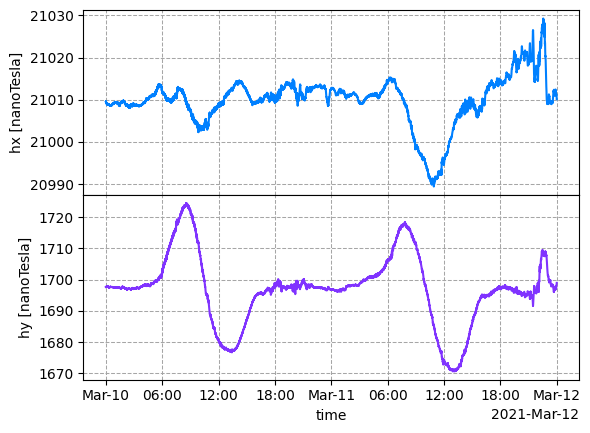

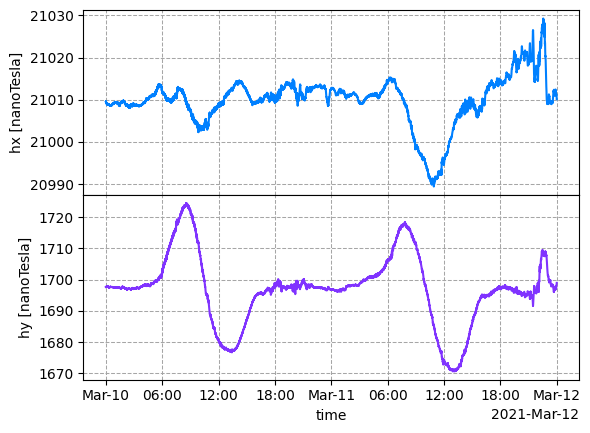

In [10]:
run_ts = run.to_runts()
run_ts.plot()

## Close the MTH5 file

**THIS STEP IS IMPORTANT**: Always close your files after you are done using them. There are plenty of indeterminate behaviors and other bad things that can happen if you leave your handles open.

In [11]:
m.close_mth5()

2026-05-15T12:47:17.973062-0600 | INFO | mth5.mth5 | close_mth5 | line: 1035 | Flushing and closing intermag_wic_xy.h5
